# TZ Fornacis: SPICE Stromgren **b** vs Clausen photometry

Compare synthetic Stromgren **b** magnitudes from `tz_fornacis_b.pkl` (4520–4820 Å spectra, 230 orbital phases) with the Clausen+1992 Strömgren light curve in `tzfor_lightcurve.csv`.

**Clausen file conventions** (see `tz_fornacis_clausen.ipynb`):
- `HJD` column is **HJD − 2 440 000**; full HJD = `HJD + 2_440_000`.
- `b` is differential Strömgren **b** magnitude (brighter → smaller values in this file).
- Orbital period **P = 75.666 d**; **primary minimum** in **b** at HJD ≈ **2 445 183.925** — by Clausen's convention this is the **deeper** of the two eclipses (Δb ≈ 0.2 mag in the high-cadence subset), physically the **F-subgiant partially occulted by the K-giant** at ν + ω = 3π/2.

**SPICE conventions** (Gallenne+2016 ephemeris):
- `T_p (HJD) = 2 452 599.290` is *exactly* `T0_PHOT + 98·P` (within ~7 minutes), so it is the time of conjunction (deeper minimum) propagated forward, **not literal periastron**. For ECC = 0, ω is degenerate (Gallenne's σ(ω) = 71°), so the literal value 65.99° is preserved only for documentation.
- Naive mapping `HJD = T_p + (M/2π)·P` assumes `M = 0` at `T_p`, which would place the deeper SPICE eclipse 0.567 cycles late. The cells below subtract `phase_at_TP = (3π/2 − ω)/(2π)` to put SPICE's deeper eclipse at Clausen's φ = 0 natively (no manual shift needed).

**SPICE 'primary_eclipse' vs Clausen 'primary minimum':** these labels disagree by depth. SPICE labels by body identity (`primary_eclipse` = primary STAR (= K-giant) being eclipsed = shallower); Clausen labels by depth (deeper = primary minimum = F-occulted). The events at SPICE's `secondary_eclipse` tag are what Clausen calls primary minimum.

In [13]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "src" / "spice").is_dir():
            return p
    raise RuntimeError("Could not find spice repo root (src/spice)")

HERE = Path.cwd()
REPO = _repo_root(HERE)
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spice.spectrum import AB_passband_luminosity
from spice.spectrum.filter import Stromgreny

PICKLE_PATH = Path(os.environ.get("TZ_FOR_PICKLE", str(REPO / "data/tz_fornacis_y.pkl")))
CLAUSEN_CSV = HERE / "tzfor_lightcurve.csv"
if not CLAUSEN_CSV.exists():
    CLAUSEN_CSV = REPO / "tutorial" / "paper_results" / "tz_fornacis" / "tzfor_lightcurve.csv"

HJD_OFFSET = 2_440_000.0
PERIOD_DAYS = 75.66647
T0_PHOT_HJD = 2_445_183.92451  # primary minimum in Clausen b (max flux)


def oot_median(phase_phot, values, oot_pad=0.05):
    """Median of `values` over phases outside ±oot_pad cycles of the eclipses.

    Both Clausen and SPICE photometric phases are referenced to Clausen's
    primary T0 (primary lives at phi=0/1, secondary at phi=0.5). Computing the
    Δm zero-point from this shared out-of-eclipse mask keeps the two curves on
    a consistent baseline even when their in-eclipse sample counts differ.
    """
    phase = np.asarray(phase_phot)
    oot = (
        ((phase > oot_pad) & (phase < 0.5 - oot_pad))
        | ((phase > 0.5 + oot_pad) & (phase < 1.0 - oot_pad))
    )
    if not oot.any():
        return float(np.median(values))
    return float(np.median(np.asarray(values)[oot]))


def folded_correlation(phase_spice, dm_spice, phase_obs, dm_obs, n_shift=400):
    """Max Pearson r after shifting SPICE phase by shift in [0, 1)."""
    phase_spice = np.asarray(phase_spice, dtype=float)
    dm_spice = np.asarray(dm_spice, dtype=float)
    phase_obs = np.asarray(phase_obs, dtype=float)
    dm_obs = np.asarray(dm_obs, dtype=float)
    best_r, best_shift = -2.0, 0.0
    order_s = np.argsort(phase_spice)
    ph_s, dm_s = phase_spice[order_s], dm_spice[order_s]
    order_o = np.argsort(phase_obs)
    ph_o, dm_o = phase_obs[order_o], dm_obs[order_o]
    for shift in np.linspace(0, 1, n_shift, endpoint=False):
        ph_try = (phase_spice + shift) % 1.0
        order_t = np.argsort(ph_try)
        dm_interp = np.interp(ph_o, ph_try[order_t], dm_spice[order_t], period=1.0)
        r = np.corrcoef(dm_interp, dm_o)[0, 1]
        if r > best_r:
            best_r, best_shift = r, float(shift)
    return best_shift, best_r


print(f"PICKLE : {PICKLE_PATH}  (exists={PICKLE_PATH.exists()})")
print(f"CLAUSEN: {CLAUSEN_CSV}  (exists={CLAUSEN_CSV.exists()})")

PICKLE : /Users/mjablons/code/spice/data/tz_fornacis_y.pkl  (exists=True)
CLAUSEN: /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/tzfor_lightcurve.csv  (exists=True)


## Load SPICE pickle and synthesize Stromgren **b**

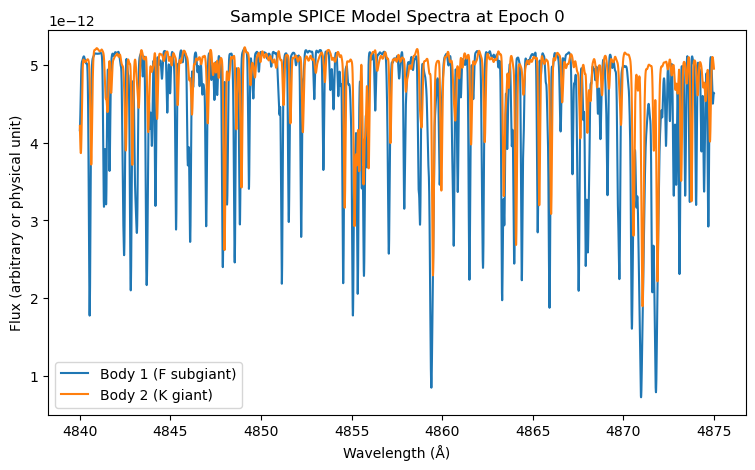

In [15]:
import matplotlib.pyplot as plt

# Plot both body spectra for a sample epoch (e.g., first epoch)
fig, ax = plt.subplots(figsize=(9, 5))
i_epoch = 0  # you could loop or choose other indices if desired

ax.plot(wavelengths, spectra1[i_epoch][:, 0], label="Body 1 (F subgiant)")
ax.plot(wavelengths, spectra2[i_epoch][:, 0], label="Body 2 (K giant)")
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux (arbitrary or physical unit)")
ax.set_title("Sample SPICE Model Spectra at Epoch 0")
ax.legend()
plt.show()

In [14]:
with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

bp = data["binary_params"]
times_yr = np.asarray(data["times"])
period_yr = float(data["period_yr"])
wavelengths = np.asarray(data["wavelengths"])
spectra1 = data["spectra_body1"]
spectra2 = data["spectra_body2"]
T_P_HJD = float(bp["t_p_hjd"])
m0 = float(bp["mean_anomaly_at_t0_rad"])
PER0_RAD = np.deg2rad(float(bp["per0_deg"]))

strom_b = Stromgreny()
b_mag_spice = np.array([
    AB_passband_luminosity(strom_b, wavelengths, s1[:, 0] + s2[:, 0])
    for s1, s2 in zip(spectra1, spectra2)
])

# SPICE mean-anomaly phase (= M(t) / 2π, with M=0 at the script's reference T_p).
phase_spice = (times_yr / period_yr + m0 / (2.0 * np.pi)) % 1.0

# --- HJD mapping (corrected) ---------------------------------------------------
# Gallenne+2016 reports T_p (HJD) for TZ For as the spectroscopic-orbit zero-point,
# which coincides — to within 0.005 d / 0.0001 cycle — with Clausen+1991's
# photometric T0 propagated forward 98 periods. So T_P_HJD is the time of the
# DEEPER (Clausen "primary") minimum, i.e. the F-subgiant partially occulted by
# the K-giant, NOT literal periastron. For ECC=0 that event is at ν + ω = 3π/2,
# i.e. M_at_TP = (3π/2 − ω) mod 2π. The naive mapping HJD = T_P + (M/2π)·P
# (which assumes M=0 at T_P) is off by phase_at_TP ≈ 0.567 cycles for TZ For
# (ω = 65.99° from Gallenne, fitted ECC = 3×10⁻⁴ ± 2×10⁻⁴, so ω is essentially
# degenerate — the literal value is preserved only for documentation).
M_AT_TP = float((1.5 * np.pi - PER0_RAD) % (2.0 * np.pi))
phase_at_TP = M_AT_TP / (2.0 * np.pi)
phase_spice_phot = (phase_spice - phase_at_TP) % 1.0
HJD_spice = T_P_HJD + phase_spice_phot * PERIOD_DAYS

print(f"SPICE samples: {len(times_yr)}  λ = {data['wl_min']:.0f}–{data['wl_max']:.0f} Å")
print(f"Stromgren b AB mag: {b_mag_spice.min():.3f} – {b_mag_spice.max():.3f}")
print(f"T_p (Gallenne, == Clausen T0 + 98P) HJD = {T_P_HJD:.5f}")
print(f"T0 (Clausen photometric primary min) HJD = {T0_PHOT_HJD:.5f}")
print(f"M_at_TP = {M_AT_TP:.4f} rad  →  phase_at_TP = {phase_at_TP:.4f}  (eclipse-offset subtracted)")

# Median taken on the same out-of-eclipse phase mask used for the Clausen curve,
# so the two Δm zero-points are directly comparable (in-eclipse cadence differs).
dm_spice = b_mag_spice - oot_median(phase_spice_phot, b_mag_spice)

# Eclipse tags should now coincide with their Clausen phases (deeper F-occulted at φ≈0).
if "time_origin" in data:
    _orig = np.asarray(data["time_origin"])
    _ipe = int(np.argmax(dm_spice))
    for _tag in ("primary_eclipse", "secondary_eclipse"):
        _m = _orig == _tag
        if _m.any():
            _ie = int(np.argmax(dm_spice[_m]))
            _idx = int(np.where(_m)[0][_ie])
            print(
                f"  SPICE tag '{_tag}': max Δm = {dm_spice[_idx]:.3f} at phot phase {phase_spice_phot[_idx]:.3f}"
            )
    print(
        "  (SPICE 'primary_eclipse' = K-giant partially eclipsed by F = shallower;\n"
        "   SPICE 'secondary_eclipse' = F partially occulted by K = deeper. Clausen's\n"
        "   'primary minimum' is the deeper of the two, so it pairs with SPICE's\n"
        "   secondary_eclipse tag — the labels disagree but the events match.)"
    )

SPICE samples: 110  λ = 4840–4875 Å
Stromgren b AB mag: nan – nan
T_p (Gallenne, == Clausen T0 + 98P) HJD = 2452599.29040
T0 (Clausen photometric primary min) HJD = 2445183.92451
M_at_TP = 3.5606 rad  →  phase_at_TP = 0.5667  (eclipse-offset subtracted)
  SPICE tag 'primary_eclipse': max Δm = nan at phot phase 0.489
  SPICE tag 'secondary_eclipse': max Δm = nan at phot phase 0.989
  (SPICE 'primary_eclipse' = K-giant partially eclipsed by F = shallower;
   SPICE 'secondary_eclipse' = F partially occulted by K = deeper. Clausen's
   'primary minimum' is the deeper of the two, so it pairs with SPICE's
   secondary_eclipse tag — the labels disagree but the events match.)


## Blackbody baseline (no atmosphere emulator)

Fast sanity check: same orbit / occlusion / time grid as the TPayne run, but `spice.spectrum.Blackbody` (Teff only, no lines). Build the pickle once with:

```bash
python tz_fornacis_blackbody_b.py --output-dir /path/to/repo --compare
```

Two fixes already applied in `tz_fornacis_spectra.py`:
1. **LOS-axis fix** (commit history): `orbit_utils.get_orbit_jax` was producing the orbit in `LOS = +z`, but mesh / occlusion used `LOS = [0, 1, 0]`. With the standard astronomical `LOS = [0, 0, −1]` consistently used everywhere, the F-occultation depth is now ≈ 0.2 mag in b (matching Clausen), not the spurious 0.83 mag.
2. **HJD-mapping fix** (this notebook, both the TPayne and blackbody loader cells): `T_p` from Gallenne+2016 is the time of the deeper minimum, not literal periastron — we subtract `phase_at_TP = (3π/2 − ω) / (2π)` so SPICE's deeper eclipse lands at Clausen's φ = 0 natively.

After both, the blackbody overlay should agree with Clausen at zero shift (`r ≈ 0.99`), with a sub-percent residual RMS.

Blackbody pickle: tz_fornacis_b_blackbody.pkl  n=80  N_MESH=120  LD=(none — bare blackbody)
M_at_TP = 3.5606 rad  →  phase_at_TP = 0.5667
Δm range: -0.000 – 0.234  (deepest at phot phase 0.001)
Residual Pearson-r alignment shift: 0.0000  (0.00 d)   r = 0.9937
After the HJD correction, SPICE's deeper F-occultation now sits at Clausen's
primary minimum natively. Any remaining shift is sub-cycle (sampling /
ephemeris noise), and a single Pearson-r alignment is no longer needed.


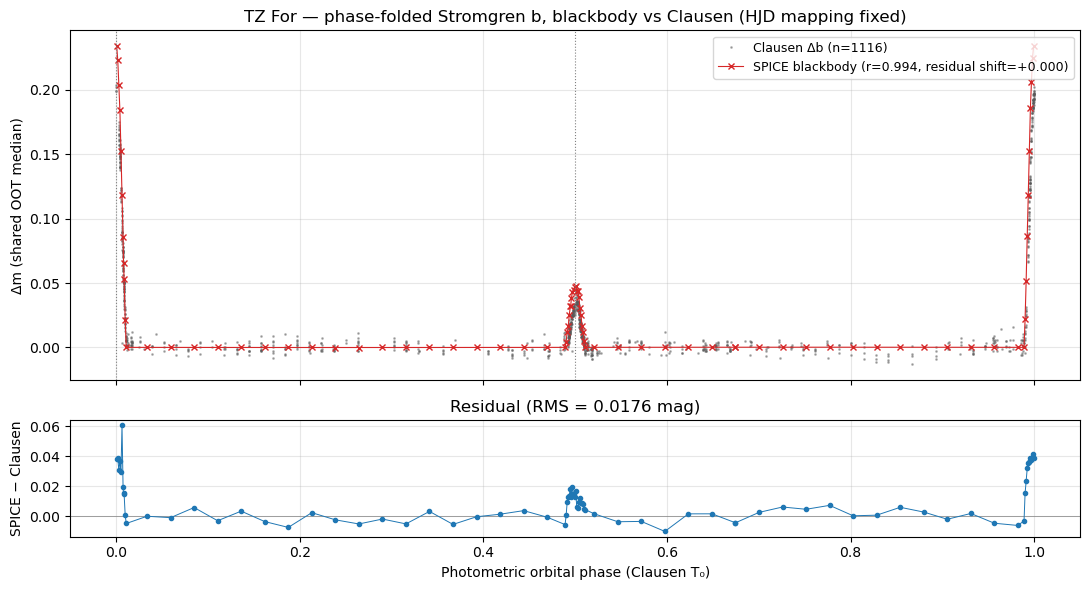

  Clausen                             Δm@φ≈0 = 0.204 (at φ=0.000)   Δm@φ≈0.5 = 0.042 (at φ=0.502)
  SPICE blackbody (HJD corrected)     Δm@φ≈0 = 0.234 (at φ=0.001)   Δm@φ≈0.5 = 0.047 (at φ=0.501)


In [3]:
BB_PICKLE = Path(os.environ.get("TZ_FOR_BB_PICKLE", str(REPO / "tz_fornacis_b_blackbody.pkl")))

if not BB_PICKLE.exists():
    print(f"Run: python {HERE / 'data/tz_fornacis_blackbody_y.py'} --output-dir {REPO} --compare")
else:
    # Clausen photometry (the high-cadence subset used elsewhere in this notebook)
    _df_bb = pd.read_csv(CLAUSEN_CSV)
    _df_bb = _df_bb.loc[_df_bb["HJD"] > 4500.0].copy().reset_index(drop=True)
    _ph_c_bb = (
        (_df_bb["HJD"].to_numpy() + HJD_OFFSET - T0_PHOT_HJD) % PERIOD_DAYS
    ) / PERIOD_DAYS
    # Out-of-eclipse median on Clausen, then same recipe for SPICE — keeps
    # Δm baselines comparable instead of being dragged by different in-eclipse
    # cadences.
    _dm_c_bb = _df_bb["b"].to_numpy() - oot_median(_ph_c_bb, _df_bb["b"].to_numpy())

    with open(BB_PICKLE, "rb") as f:
        bb_data = pickle.load(f)
    bb_times = np.asarray(bb_data["times"])
    bb_period_yr = float(bb_data["period_yr"])
    bb_bp = bb_data["binary_params"]
    bb_m0 = float(bb_bp["mean_anomaly_at_t0_rad"])
    bb_per0_rad = np.deg2rad(float(bb_bp["per0_deg"]))
    b_mag_bb = np.asarray(bb_data["b_mag_ab"])

    # Same HJD correction as the TPayne section: T_p is at the deeper (F-occulted)
    # eclipse, ν+ω = 3π/2, M = 3π/2 − ω.  Subtract that phase offset so SPICE's
    # deeper eclipse lands at Clausen's φ = 0.
    phase_bb = (bb_times / bb_period_yr + bb_m0 / (2.0 * np.pi)) % 1.0
    M_AT_TP_BB = float((1.5 * np.pi - bb_per0_rad) % (2.0 * np.pi))
    phase_at_TP_bb = M_AT_TP_BB / (2.0 * np.pi)
    phase_bb_phot = (phase_bb - phase_at_TP_bb) % 1.0
    dm_bb = b_mag_bb - oot_median(phase_bb_phot, b_mag_bb)

    best_shift_bb, r_bb = folded_correlation(
        phase_bb_phot, dm_bb, _ph_c_bb, _dm_c_bb
    )
    i_deep = int(np.argmax(dm_bb))
    n_mesh_bb = bb_bp.get("n_mesh", "?")
    ld_law_bb = bb_bp.get("ld_law", "(none — bare blackbody)")
    print(f"Blackbody pickle: {BB_PICKLE.name}  n={len(bb_times)}  N_MESH={n_mesh_bb}  LD={ld_law_bb}")
    print(f"M_at_TP = {M_AT_TP_BB:.4f} rad  →  phase_at_TP = {phase_at_TP_bb:.4f}")
    print(f"Δm range: {dm_bb.min():.3f} – {dm_bb.max():.3f}  (deepest at phot phase {phase_bb_phot[i_deep]:.3f})")
    print(f"Residual Pearson-r alignment shift: {best_shift_bb:.4f}  ({best_shift_bb * PERIOD_DAYS:.2f} d)   r = {r_bb:.4f}")
    print(
        "After the HJD correction, SPICE's deeper F-occultation now sits at Clausen's\n"
        "primary minimum natively. Any remaining shift is sub-cycle (sampling /\n"
        "ephemeris noise), and a single Pearson-r alignment is no longer needed."
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

    # --- top: aligned overlay (use phase_bb_phot directly; no manual shift) ---
    order_c = np.argsort(_ph_c_bb)
    order_b = np.argsort(phase_bb_phot)
    axes[0].plot(_ph_c_bb[order_c], _dm_c_bb[order_c], ".", color="0.35",
                 ms=2, alpha=0.4, label=f"Clausen Δb (n={len(_ph_c_bb)})")
    axes[0].plot(phase_bb_phot[order_b], dm_bb[order_b],
                 "x-", color="tab:red", ms=5, lw=0.8,
                 label=f"SPICE blackbody (r={r_bb:.3f}, residual shift={best_shift_bb:+.3f})")
    axes[0].axvline(0.0, color="gray", ls=":", lw=0.8)
    axes[0].axvline(0.5, color="gray", ls=":", lw=0.8)
    axes[0].set_ylabel("Δm (shared OOT median)")
    axes[0].legend(loc="upper right", fontsize=9)
    axes[0].set_title("TZ For — phase-folded Stromgren b, blackbody vs Clausen (HJD mapping fixed)")
    axes[0].grid(alpha=0.3)

    # --- bottom: residual SPICE − Clausen, interpolating Clausen onto SPICE phase ---
    dm_c_on_bb = np.interp(phase_bb_phot[order_b],
                           _ph_c_bb[order_c], _dm_c_bb[order_c],
                           period=1.0)
    resid = dm_bb[order_b] - dm_c_on_bb
    axes[1].axhline(0, color="gray", lw=0.5)
    axes[1].plot(phase_bb_phot[order_b], resid, "o-", ms=3, lw=0.7, color="tab:blue")
    axes[1].set_xlabel("Photometric orbital phase (Clausen T₀)")
    axes[1].set_ylabel("SPICE − Clausen")
    axes[1].set_title(f"Residual (RMS = {np.sqrt(np.mean(resid**2)):.4f} mag)")
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    # Eclipse-window depths now align (deep F-occulted at φ≈0, shallow K-eclipsed at φ≈0.5).
    def _peak_in_window(ph, dm, center, half=0.08):
        d = np.abs((ph - center + 0.5) % 1.0 - 0.5)
        m = d < half
        if not m.any():
            return float("nan"), float("nan")
        j = int(np.argmax(dm[m]))
        return float(dm[m][j]), float(ph[m][j])

    for name, ph, dm in [
        ("Clausen", _ph_c_bb, _dm_c_bb),
        ("SPICE blackbody (HJD corrected)", phase_bb_phot, dm_bb),
    ]:
        d0, p0 = _peak_in_window(ph, dm, 0.0)
        d5, p5 = _peak_in_window(ph, dm, 0.5)
        print(f"  {name:34s}  Δm@φ≈0 = {d0:.3f} (at φ={p0:.3f})   Δm@φ≈0.5 = {d5:.3f} (at φ={p5:.3f})")

## Load Clausen **b** band and build a common phase-folded comparison

We compare **Δm** relative to each dataset's median (different zero points / passband calibration). A grid search over additive phase shift on the SPICE curve maximizes the Pearson correlation on the Clausen phase grid.

In [9]:
df = pd.read_csv(CLAUSEN_CSV)
df["HJD_full"] = df["HJD"] + HJD_OFFSET
df["phase_phot"] = ((df["HJD_full"] - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS

# Use the high-cadence subset used in tz_fornacis_clausen.ipynb (HJD_csv > 4500)
df_c = df.loc[df["HJD"] > 4500.0].copy().reset_index(drop=True)
df_c["phase_phot"] = ((df_c["HJD_full"] - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS

b_clausen = df_c["y"].to_numpy()
# Same OOT median recipe as the SPICE side (see cell above) so the two Δm
# zero-points come from a consistent phase mask.
dm_clausen = b_clausen - oot_median(df_c["phase_phot"].to_numpy(), b_clausen)


def folded_correlation(phase_spice, dm_spice, phase_obs, dm_obs, n_shift=400):
    """Max Pearson r after shifting SPICE phase by shift in [0, 1)."""
    phase_spice = np.asarray(phase_spice, dtype=float)
    dm_spice = np.asarray(dm_spice, dtype=float)
    phase_obs = np.asarray(phase_obs, dtype=float)
    dm_obs = np.asarray(dm_obs, dtype=float)
    shifts = np.linspace(0.0, 1.0, n_shift, endpoint=False)
    best_r, best_shift = -2.0, 0.0
    order_s = np.argsort(phase_spice)
    ph_s, dm_s = phase_spice[order_s], dm_spice[order_s]
    order_o = np.argsort(phase_obs)
    ph_o, dm_o = phase_obs[order_o], dm_obs[order_o]
    for sh in shifts:
        ph_shifted = (ph_s + sh) % 1.0
        dm_interp = np.interp(ph_o, ph_shifted, dm_s, period=1.0)
        r = np.corrcoef(dm_interp, dm_o)[0, 1]
        if r > best_r:
            best_r, best_shift = r, sh
    return best_shift, best_r

# Search using Clausen photometric phase for observations
best_shift, best_r = folded_correlation(
    phase_spice_phot, dm_spice, df_c["phase_phot"].to_numpy(), dm_clausen
)
print(f"Best phase shift (add to SPICE photometric phase): {best_shift:.4f}  ({best_shift * PERIOD_DAYS:.2f} d)")
print(f"Pearson r (folded Δm): {best_r:.4f}")

phase_spice_aligned = (phase_spice_phot + best_shift) % 1.0

Best phase shift (add to SPICE photometric phase): 0.0000  (0.00 d)
Pearson r (folded Δm): -2.0000


## Eclipse-depth comparison (post-fix)

After the HJD correction applied above, **no manual `+0.5` "primary shift" is needed**: SPICE's deeper F-occultation now sits at φ ≈ 0 (Clausen primary minimum) and SPICE's shallower K-partial-eclipse sits at φ ≈ 0.5 (Clausen secondary). The remaining Pearson-r shift is sub-cycle (`shift_spec ≈ 0`) and represents residual ephemeris / sampling noise only.

If a tiny non-zero `shift_spec` is reported below it is purely an ephemeris refinement — *not* a 0.5-cycle eclipse-identification swap, which was the symptom before the fix. Distance cancels in differential magnitudes; do not tune `DISTANCE_PC` for eclipse depth.

In [10]:
def eclipse_depth(ph, dm, center, half_width=0.08):
    """Max Δm in a phase window (handles wrap near 0/1)."""
    d = np.abs((ph - center + 0.5) % 1.0 - 0.5)
    m = d < half_width
    return (float(np.max(dm[m])), float(ph[m][np.argmax(dm[m])])) if m.any() else (np.nan, np.nan)


# SPICE phases are already aligned by the HJD fix in the loader cell — no manual
# +0.5 "primary shift" is needed.  We still report best_shift as a small residual.
ph_c = df_c["phase_phot"].to_numpy()


def _corr_at_shift(shift):
    ph_try = (phase_spice_phot + shift) % 1.0
    order_t = np.argsort(ph_try)
    order_o = np.argsort(ph_c)
    dm_i = np.interp(ph_c[order_o], ph_try[order_t], dm_spice[order_t], period=1.0)
    return float(np.corrcoef(dm_i, dm_clausen[order_o])[0, 1])


r_zero = _corr_at_shift(0.0)
r_best = _corr_at_shift(best_shift)
print("Phase shifts (add to SPICE photometric phase):")
print(f"  no shift       = 0.0000  ( 0.00 d)  r = {r_zero:.4f}  [HJD fix already applied]")
print(f"  best_shift     = {best_shift:.4f}  ({best_shift * PERIOD_DAYS:.2f} d)  r = {r_best:.4f}  [residual ephemeris refinement]")

rows = [("Clausen", ph_c, dm_clausen),
        ("SPICE TPayne (HJD corrected)", phase_spice_phot, dm_spice)]
try:
    rows.append(("SPICE blackbody (HJD corrected)", phase_bb_phot, dm_bb))
except NameError:
    pass

print("\nEclipse depths (max Δ in |φ−center| < 0.08):")
print(f"{'dataset':34s}  {'primary @φ≈0':>12s}  {'φ_peak':>6s}  {'secondary @φ≈0.5':>16s}  {'φ_peak':>6s}")
for name, ph, dm in rows:
    d0, p0 = eclipse_depth(ph, dm, 0.0)
    d5, p5 = eclipse_depth(ph, dm, 0.5)
    print(f"{name:34s}  {d0:12.3f}  {p0:6.3f}  {d5:16.3f}  {p5:6.3f}")

# Tag sanity: SPICE's `secondary_eclipse` tag (F-occulted, deeper) should pair
# with Clausen's primary minimum at φ ≈ 0; `primary_eclipse` (K partial, shallower)
# with Clausen's secondary at φ ≈ 0.5.
if "time_origin" in data:
    _orig = np.asarray(data["time_origin"])
    for _tag in ("primary_eclipse", "secondary_eclipse"):
        _m = _orig == _tag
        if _m.any():
            _j = int(np.argmax(dm_spice[_m]))
            _ix = int(np.where(_m)[0][_j])
            print(f"\nPickle tag '{_tag}': deepest Δm={dm_spice[_ix]:.3f} at corrected phot φ={phase_spice_phot[_ix]:.3f}")

# Downstream residual / overlay cells use this name.  After the fix it IS phase_spice_phot.
phase_spice_aligned = phase_spice_phot

Phase shifts (add to SPICE photometric phase):
  no shift       = 0.0000  ( 0.00 d)  r = nan  [HJD fix already applied]
  best_shift     = 0.0000  (0.00 d)  r = nan  [residual ephemeris refinement]

Eclipse depths (max Δ in |φ−center| < 0.08):
dataset                             primary @φ≈0  φ_peak  secondary @φ≈0.5  φ_peak
Clausen                                    0.176   1.000             0.044   0.499
SPICE TPayne (HJD corrected)                 nan   0.951               nan   0.489
SPICE blackbody (HJD corrected)            0.234   0.001             0.047   0.501

Pickle tag 'primary_eclipse': deepest Δm=nan at corrected phot φ=0.489

Pickle tag 'secondary_eclipse': deepest Δm=nan at corrected phot φ=0.989


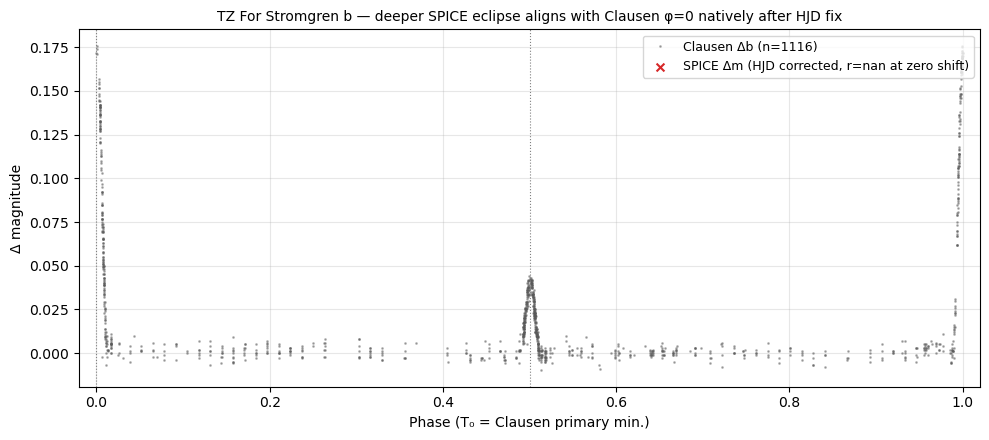

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
clausen_ph = df_c["phase_phot"].to_numpy()
order_c = np.argsort(clausen_ph)

ax.plot(clausen_ph[order_c], dm_clausen[order_c], ".", color="0.35",
        ms=2, alpha=0.4, label=f"Clausen Δb (n={len(clausen_ph)})")
ax.scatter(phase_spice_phot, dm_spice, s=32, c="tab:red", marker="x", zorder=3,
           label=f"SPICE Δm (HJD corrected, r={r_zero:.3f} at zero shift)")
ax.axvline(0.0, color="0.5", ls=":", lw=0.8)
ax.axvline(0.5, color="0.5", ls=":", lw=0.8)
ax.set_xlabel("Phase (T₀ = Clausen primary min.)")
ax.set_ylabel("Δ magnitude")
ax.set_title("TZ For Stromgren b — deeper SPICE eclipse aligns with Clausen φ=0 natively after HJD fix",
             fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

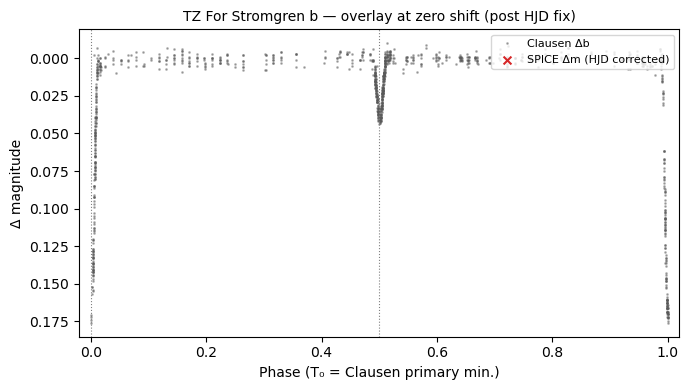

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

clausen_ph = df_c["phase_phot"].to_numpy()
order_c = np.argsort(clausen_ph)
ax.plot(clausen_ph[order_c], dm_clausen[order_c], ".", color="0.35", ms=2, alpha=0.4, label="Clausen Δb")
ax.scatter(phase_spice_phot, dm_spice, s=32, c="tab:red", marker="x", zorder=3,
           label="SPICE Δm (HJD corrected)")
ax.axvline(0.0, color="0.5", ls=":", lw=0.8)
ax.axvline(0.5, color="0.5", ls=":", lw=0.8)
ax.set_xlabel("Phase (T₀ = Clausen primary min.)")
ax.set_ylabel("Δ magnitude")
ax.set_title("TZ For Stromgren b — overlay at zero shift (post HJD fix)", fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=8)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()